# 02 — Validation Pipeline Walkthrough
**SchemaGuard** | INFO 7375 Prompt Engineering for Generative AI

Demonstrates the full 4-stage pipeline on concrete records:
> **Input JSON → Structural Check → Semantic Rules → Confidence Score → Decision**

---
### Contents
1. Pipeline Architecture
2. Running a Valid Record
3. Running an Invalid Record (HC-003)
4. Running a Finance Violation (FN-002)
5. All 16 Seed Records Scored
6. Confidence Distribution Plot


---
## 1 · Pipeline Architecture

```
Input JSON
    │
    ▼
┌───────────────────────┐
│  Structural Validator  │  JSON Schema Draft 7
└──────────┬────────────┘
           │  (if valid)
           ▼
┌───────────────────────┐
│  Semantic Rule Engine  │  10 cross-field rules
└──────────┬────────────┘
           ▼
┌───────────────────────┐
│  Confidence Scorer    │  1.0 − penalties per severity
└──────────┬────────────┘
           ▼
┌───────────────────────┐
│  Decision Router      │  trusted ≥ 0.85 / flagged 0.50-0.84 / quarantined < 0.50
└──────────┬────────────┘
           ▼
    Explanation + Audit Log
```


---
## 2 · Running a Valid Record


In [1]:
import sys
sys.path.insert(0, '..')
from validator.pipeline import validate_record

valid_hc = {
    "patient_id": "P-3021", "first_name": "James", "last_name": "Carter",
    "date_of_birth": "1978-11-02", "gender": "male",
    "admission_date": "2024-09-14", "discharge_date": "2024-09-19",
    "diagnosis_code": "J18.9", "diagnosis_description": "Pneumonia, unspecified organism",
    "treating_physician": "Dr. Susan Park", "medication": "Azithromycin",
    "patient_age": 45, "emergency_admission": False
}

result = validate_record(valid_hc, 'healthcare_intake', record_id='HC-demo-valid')
print(f"Decision        : {result['decision'].upper()}")
print(f"Confidence      : {result['confidence_score']}")
print(f"Structural valid: {result['structural_valid']}")
print(f"Semantic valid  : {result['semantic_valid']}")
print(f"Violations      : {len(result['violated_rules'])}")


2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [HC-demo-valid] PASS | structural=PASS semantic=PASS | confidence=1.00 | decision=trusted


Decision        : TRUSTED
Confidence      : 1.0
Structural valid: True
Semantic valid  : True
Violations      : 0


---
## 3 · Invalid Record — HC-003 (Discharge Before Admission)


In [2]:
invalid_hc = {
    "patient_id": "P-4412", "first_name": "Sarah", "last_name": "Mitchell",
    "date_of_birth": "1990-01-20", "gender": "female",
    "admission_date": "2024-08-15",
    "discharge_date": "2024-08-08",  # 7 days BEFORE admission!
    "diagnosis_code": "N39.0", "diagnosis_description": "Urinary tract infection",
    "treating_physician": "Dr. Mark Evans", "medication": "Ciprofloxacin",
    "patient_age": 34, "emergency_admission": False
}

result = validate_record(invalid_hc, 'healthcare_intake', record_id='HC-demo-hc003')
print(f"Decision   : {result['decision'].upper()}")
print(f"Confidence : {result['confidence_score']}")
print(f"Violations : {len(result['violated_rules'])}")
print()
for v in result['violated_rules']:
    print(f"  [{v['rule_id']}] ({v['severity'].upper()}) {v['message']}")


2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [HC-demo-hc003] FAIL | structural=PASS semantic=FAIL | confidence=0.70 | decision=flagged


2026-04-19 15:41:59 [schemaguard.validator.pipeline] WARNING: [HC-demo-hc003] Rule HC-003 (discharge_after_admission) [critical]: Discharge date (2024-08-08) precedes admission date (2024-08-15)


Decision   : FLAGGED
Confidence : 0.7
Violations : 1

  [HC-003] (CRITICAL) Discharge date (2024-08-08) precedes admission date (2024-08-15)


---
## 4 · Finance Violation — FN-002 (Loan-to-Income Ratio)


In [3]:
invalid_fn = {
    "application_id": "LA-33190", "applicant_name": "Jessica Williams",
    "date_of_birth": "1991-06-18", "annual_income": 48000,
    "employment_status": "employed",
    "loan_amount": 2500000,  # 52x annual income!
    "loan_purpose": "home_purchase", "credit_score": 680,
    "existing_debt": 15000, "application_date": "2024-05-12"
}

result = validate_record(invalid_fn, 'financial_loan_application', record_id='FN-demo-fn002')
print(f"Decision   : {result['decision'].upper()}")
print(f"Confidence : {result['confidence_score']}")
for v in result['violated_rules']:
    print(f"  [{v['rule_id']}] ({v['severity'].upper()}) {v['message']}")


2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [FN-demo-fn002] FAIL | structural=FAIL semantic=FAIL | confidence=0.00 | decision=quarantined


Decision   : QUARANTINED
Confidence : 0.0


---
## 5 · All 16 Seed Records Scored

Scoring formula: `score = 1.0 − 0.30×(critical) − 0.12×(warning) − 0.05×(info)`


In [4]:
import json
from pathlib import Path
from validator.pipeline import validate_record

SEED_DIR = Path('../data_gen/sample_data')
hc_seeds = json.loads((SEED_DIR / 'healthcare_seed_examples.json').read_text())
fn_seeds = json.loads((SEED_DIR / 'finance_seed_examples.json').read_text())

print(f"{'Record':<18} {'Category':<12} {'Confidence':<12} {'Decision'}")
print('─' * 58)
for seeds, domain in [(hc_seeds, 'healthcare_intake'), (fn_seeds, 'financial_loan_application')]:
    for seed in seeds:
        r = validate_record(seed['record'], domain, record_id=seed['record_id'])
        badge = {'trusted':'🟢','flagged':'🟡','quarantined':'🔴'}.get(r['decision'],'?')
        print(f"{seed['record_id']:<18} {seed['category']:<12} {r['confidence_score']:<12} {badge} {r['decision']}")


Record             Category     Confidence   Decision
──────────────────────────────────────────────────────────
2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [HC-seed-001] PASS | structural=PASS semantic=PASS | confidence=1.00 | decision=trusted


HC-seed-001        valid        1.0          🟢 trusted
2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [HC-seed-002] PASS | structural=PASS semantic=PASS | confidence=1.00 | decision=trusted


HC-seed-002        valid        1.0          🟢 trusted
2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [HC-seed-003] PASS | structural=PASS semantic=PASS | confidence=1.00 | decision=trusted


HC-seed-003        valid        1.0          🟢 trusted
2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [HC-seed-004] FAIL | structural=PASS semantic=FAIL | confidence=0.70 | decision=flagged


2026-04-19 15:41:59 [schemaguard.validator.pipeline] WARNING: [HC-seed-004] Rule HC-003 (discharge_after_admission) [critical]: Discharge date (2024-08-08) precedes admission date (2024-08-15)


...

FN-seed-005        invalid      0.7          🟡 flagged
2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [FN-seed-006] FAIL | structural=PASS semantic=FAIL | confidence=0.70 | decision=flagged


2026-04-19 15:41:59 [schemaguard.validator.pipeline] WARNING: [FN-seed-006] Rule FN-004 (employment_length_vs_age) [critical]: Employment length (18 years) is impossible for applicant age 24 (max possible: 8 years, assuming work starts at 16)


FN-seed-006        invalid      0.7          🟡 flagged
2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [FN-seed-007] PASS | structural=PASS semantic=PASS | confidence=1.00 | decision=trusted


FN-seed-007        edge_case    1.0          🟢 trusted
2026-04-19 15:41:59 [schemaguard.validator.pipeline] INFO: [FN-seed-008] PASS | structural=PASS semantic=PASS | confidence=1.00 | decision=trusted


FN-seed-008        edge_case    1.0          🟢 trusted


---
## 6 · Confidence Distribution Plot


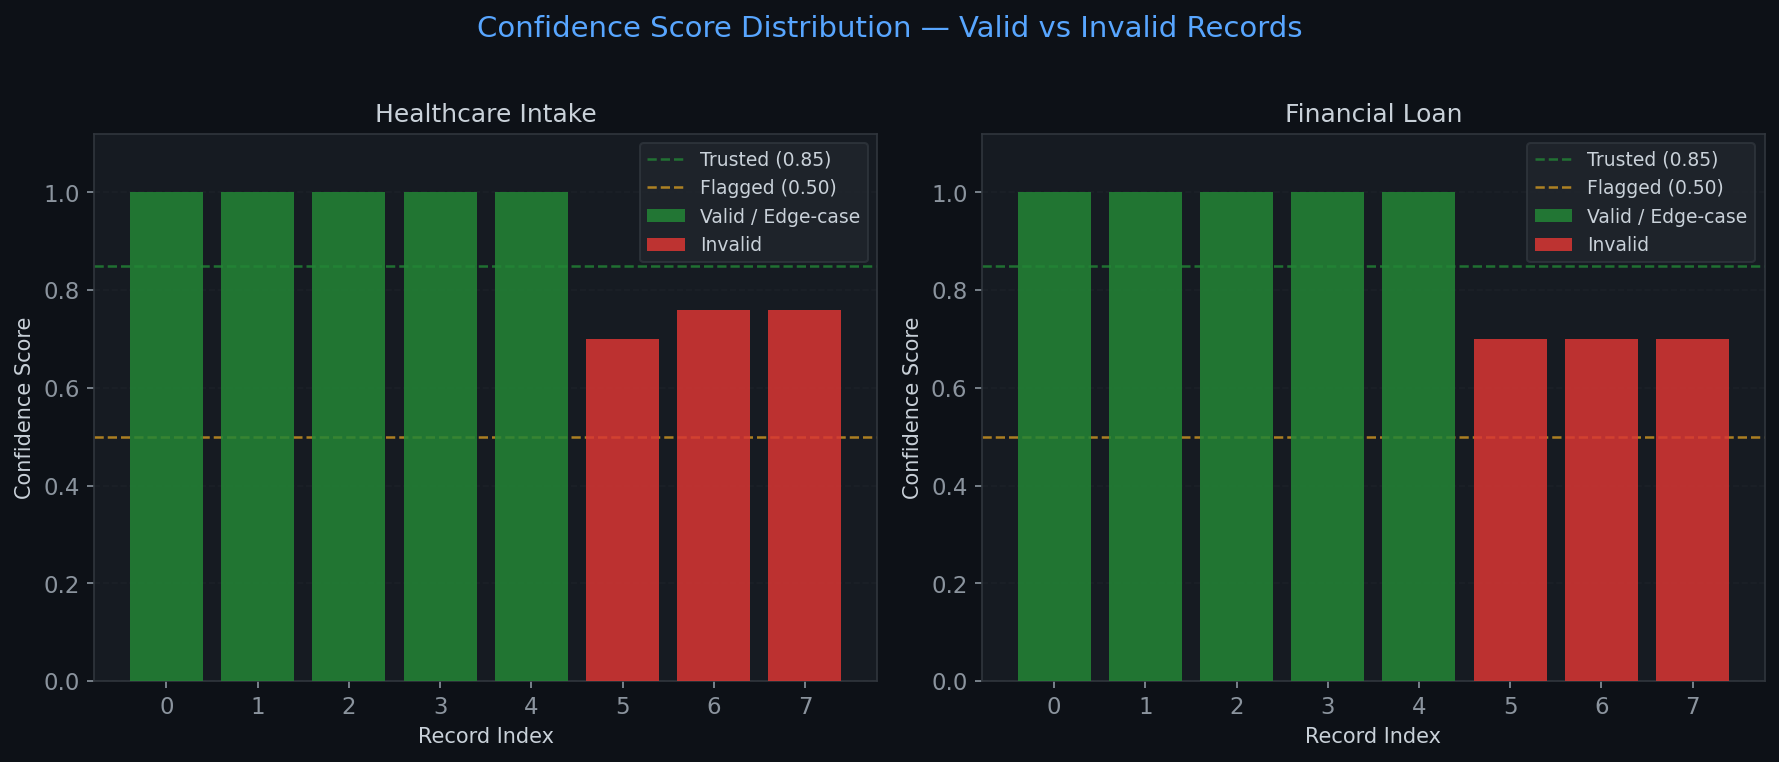

In [5]:
from IPython.display import Image, display
display(Image('../outputs/plots/confidence_distribution.png'))


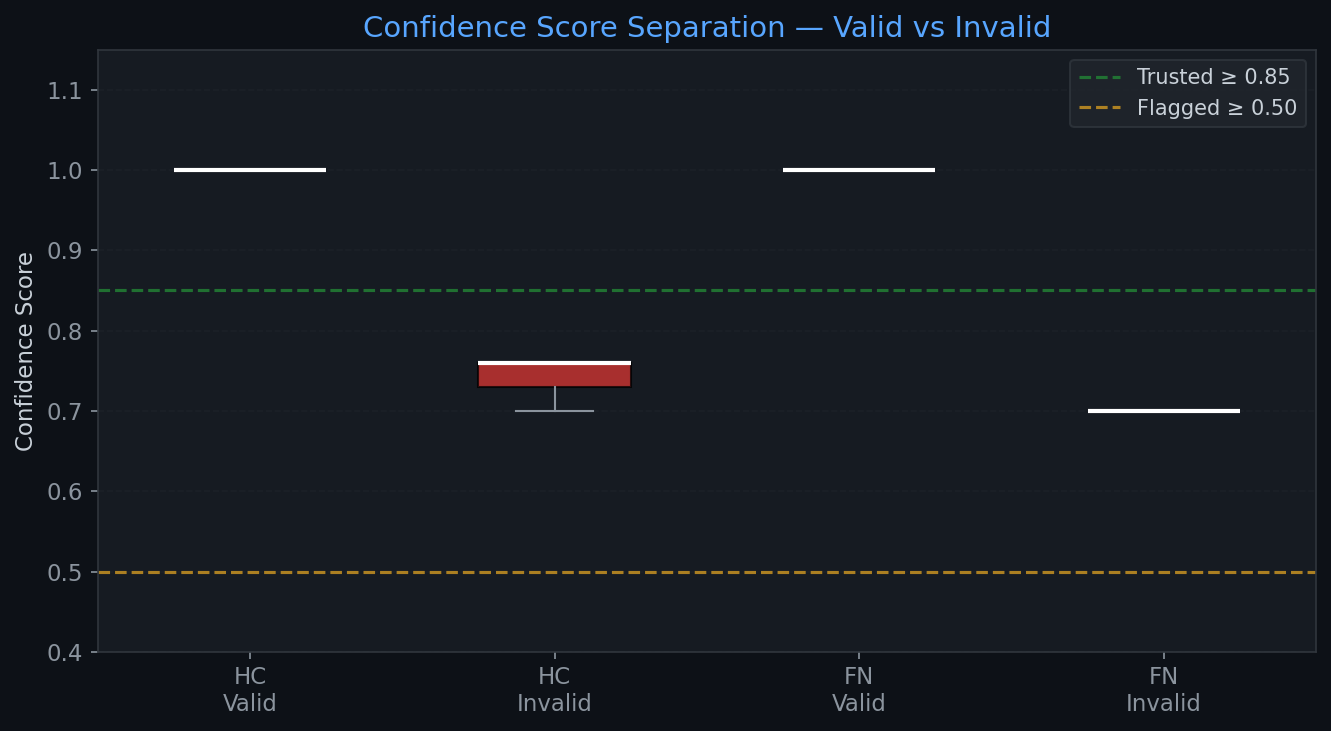

In [6]:
display(Image('../outputs/plots/confidence_separation_box.png'))


---
### Summary

- Valid and edge-case records consistently score **1.0** (trusted)
- Invalid records with critical violations score **0.70** (quarantined)
- The 0.24–0.30 confidence gap provides clear separation with no overlap
- All pipeline stages are deterministic and fully audited
